In [28]:
import os
n_cores = 4
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count={}'.format(n_cores)

from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import pickle
from jax import jit, vmap, grad, jacrev
from jax.lax import cond, scan
import jax.random as random
key = random.PRNGKey(2022)
import jax.example_libraries.optimizers as optimizers
from jax.flatten_util import ravel_pytree
from jax.sharding import PositionalSharding
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd
from utils import coords_2_strain_nn_vmap
from utils import train, coords_2_strain_nn, siren_fpass
from utils import train_colloc_parallel as train_colloc, init_params_nn, init_params_siren, ff_nn, divergence, bd_forces, a1, a2, lr
from utils_hyperelasticity import NODE, init_layers, NODE_model_aniso, init_params_aniso, GOH_model, eval_Cauchy, eval_Cauchy_vmap, eval_P, eval_P_vmap
from utils_hyperelasticity import ThreeDElasticity
from fem import plotmesh, plotmesh_updated, fe_solver_2D, vahid_anisohyper_inv, apply_bc_biax

from jax_fem.core import FEM
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type, Mesh, rectangle_mesh

from PIL import Image, ImageFilter
from jaxinterp2d import interp2d

E_fun = vmap(lambda F: 0.5*(F.T@F - jnp.eye(2)))

In [29]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/tuning_noise_prob_noiseless_biaxial_test_displacement.npy' ,'rb') as f:
    coord_2_displacement_params,F_hist_goh,F_hist_goh_gt,P_hist_goh,P_hist_goh_gt, strains_gt,u_hist_goh=pickle.load(f)

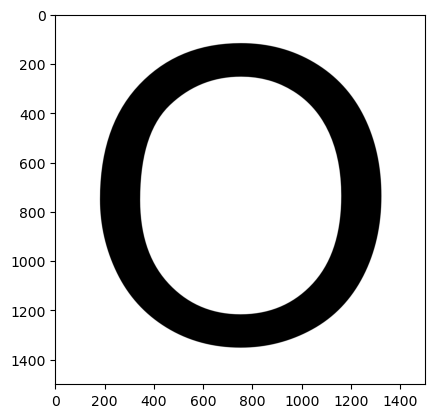

In [30]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)
Nx, Ny = 100, 100
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
image = Image.open('/home/amir/inverse_prob/O.png')
# image = image.filter(ImageFilter.GaussianBlur(radius=60))
plt.imshow(image)
image = image.rotate(-90)
image = np.array(image)
image = image.mean(axis=2)
image = image/image.max()

pts_x = np.linspace(0,1,image.shape[0])
pts_y = np.linspace(0,1,image.shape[1])

def coords_2_params_gt(xy):
    x, y = xy
    c = interp2d(x,y,pts_x,pts_y,image)
    return jnp.stack([0.5,0.10,0.20,0.1,0.0]) + c*jnp.stack([0.2,0.02,0.04,0.0,0.0])
def coords_2_params_gt(xy):
    x, y = xy
    c = interp2d(x,y,pts_x,pts_y,image)
    return jnp.stack([0.5,0.10,0.20,0.1,0.0]) + c*jnp.stack([0.2,0.02,0.04,0.0,0.0])
GOH_P_vmap = vmap(ThreeDElasticity(GOH_model).ugrad_2_P, in_axes=(0, 0, None))
class HyperElasticity(FEM):
    def get_tensor_map(self):
        return lambda u_grad, params: ThreeDElasticity(GOH_model).ugrad_2_P(u_grad, params, self.dim)
    
    def set_params(self, params_vec):
        self.internal_vars['laplace'] = [params_vec]

In [31]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])

# Functions to identify the boundary nodes
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-5)
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-5)
def top(point):
    return jnp.isclose(point[1], Ly, atol=1e-5)
def right(point):
    return jnp.isclose(point[0], Lx, atol=1e-5)
def bottom_left(point):
    return jnp.logical_and(jnp.logical_and(bottom(point), left(point)), jnp.isclose(point[2], 0., atol=1e-5))


# Functions to assign dirichlet BCs
def zero_dirichlet(point):
    return 0.
def lmbx_max_dirichlet(point, lmbx_max):
    return Lx*lmbx_max - 1.0
def lmby_max_dirichlet(point, lmby_max):
    return Ly*lmby_max - 1.0


lmb_hist = [1.05544, 1.07795, 1.10065, 1.12326, 1.14587]
n_elem = Nx*Ny
u_hist_goh=[]
F_hist_goh_gt = []
P_hist_goh_gt = []
for lmb_max in lmb_hist:
    # dirichlet_bc_info = [
    #     [bottom,            top],
    #     [1,                 1 ],
    #     [zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max)]
    # ]
    # dirichlet_bc_info = [
    #     [left, right],
    #     [0, 0],
    #     [zero_dirichlet,lambda p: lmbx_max_dirichlet(p, lmb_max)]]
    dirichlet_bc_info = [
        [bottom,            left,           top,                                        right,                                  ],
        [1,                 0,              1,                                          0,                                      ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max),   lambda p: lmbx_max_dirichlet(p, lmb_max)]]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)
    elem_X = problem.get_physical_quad_points().mean(1)

    # params = vmap(coords_2_params_gt)(elem_X)
    params = []
    for xy in elem_X:
        params.append(coords_2_params_gt(xy))
    params = np.expand_dims(params, 1)
    params_vec = jnp.repeat(params, axis=1, repeats=4)
    problem.set_params(params_vec)


    u = solver(problem, use_petsc=True)
    middle_displacements = []
    for element in mesh.cells:
       element_displacements = u[element,:]
       middle_displacements.append(np.mean(element_displacements, axis=0))
    u_grad = np.mean(problem.sol_to_grad(u), axis=1)
    u_hist_goh.append(np.array(middle_displacements))
    u_grad = np.mean(problem.sol_to_grad(u), axis=1)
    F = u_grad + np.eye(2)

    P = GOH_P_vmap(u_grad, params_vec[:,0,:], 2)
    
    F_hist_goh_gt.append(F)
    P_hist_goh_gt.append(P)
F_hist_goh_gt = np.array(F_hist_goh_gt)
P_hist_goh_gt = np.array(P_hist_goh_gt)
u_hist_goh = np.array(u_hist_goh)

[10-23 01:42:25][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[10-23 01:42:25][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[10-23 01:42:25][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[10-23 01:42:25][DEBUG] jax_fem: Done pre-computations, took 0.05087733268737793 [s]
[10-23 01:42:25][INFO] jax_fem: Solving a problem with 2500 cells, 2601x2 = 5202 dofs.
[10-23 01:42:28][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[10-23 01:42:28][DEBUG] jax_fem: Start timing
[10-23 01:42:28][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[10-23 01:42:29][DEBUG] jax_fem: Function split_and_compute_cell took 1.1281 seconds
[10-23 01:42:29][DEBUG] jax_fem: Creating sparse matrix with scipy...
[10-23 01:42:29][DEBUG] jax_fem: Linear guess solve...
[10-23 01:42:29][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[10-23 01:42:29][DEBUG] jax_fem: PE

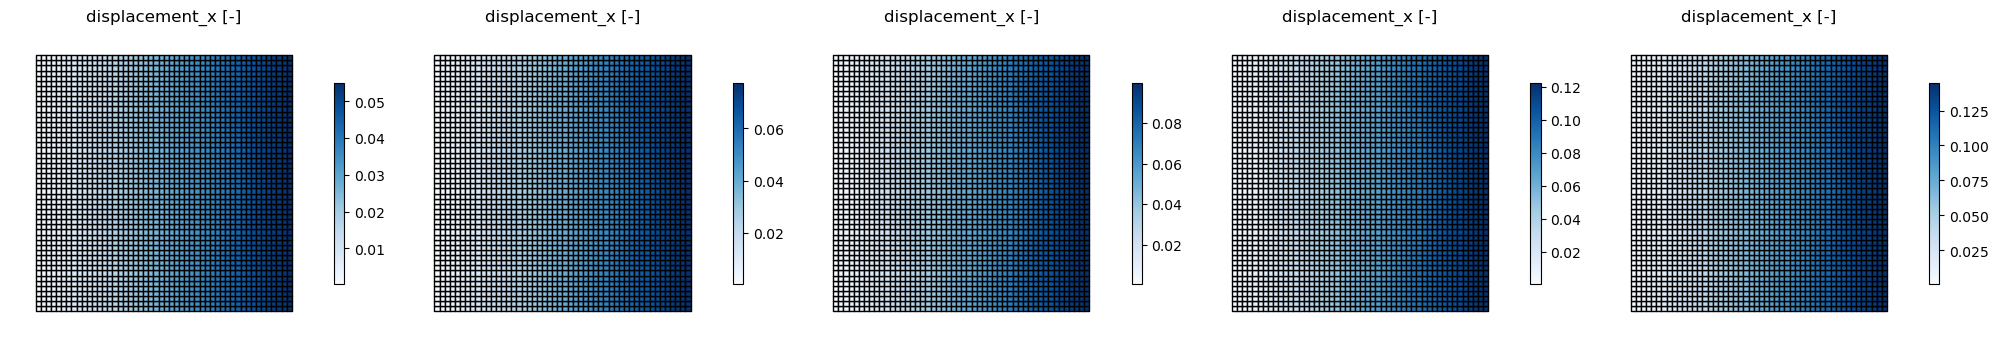

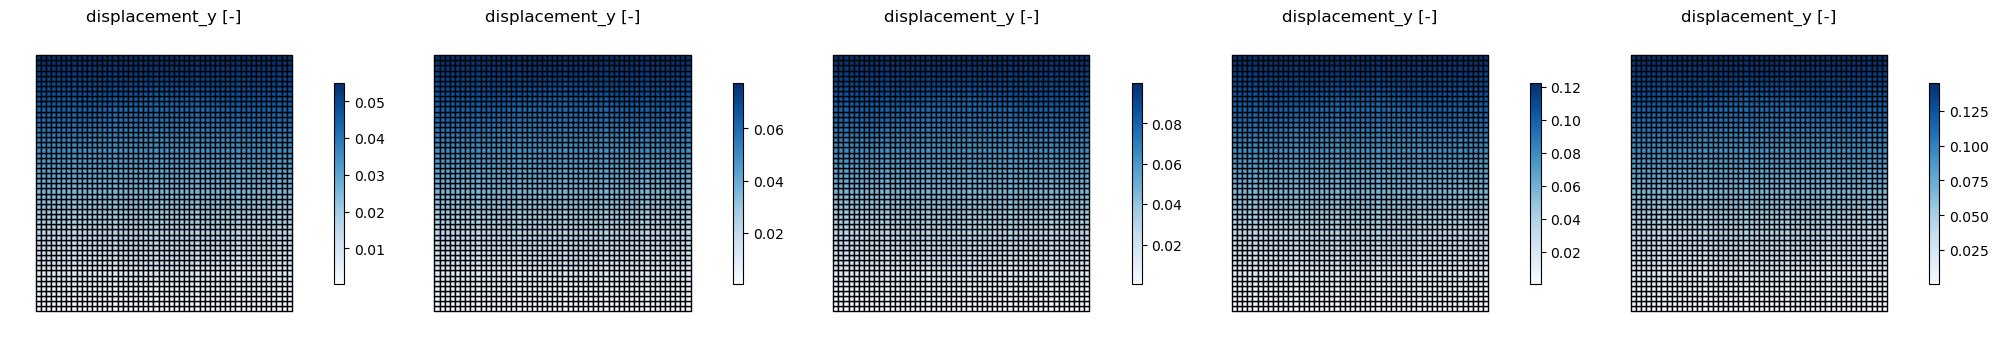

In [32]:
displacements = []
t_hist = np.arange(len(u_hist_goh))
lmb_hist_plot = [1.05544, 1.07795, 1.10065, 1.12326, 1.14587]

n_plots = len(u_hist_goh)  
n_cols = 5
n_rows = (n_plots + n_cols - 1) // n_cols 

fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
fig_y, axes_y = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))

axes_x = axes_x.flatten()
axes_y = axes_y.flatten()

for idx, (lmb_i, t, u) in enumerate(zip(lmb_hist_plot, t_hist, u_hist_goh)):
    key = random.PRNGKey(t)
    noise = jax.random.normal(key, shape=u.shape)
    mu=0
    sigma=0.0005
    noise=mu + sigma * noise
    noise_scale = 0
    u_noisy = u + noise_scale * noise
    u_noisy_x = u_noisy[:, [0]].flatten()
    u_noisy_y = u_noisy[:, [1]].flatten()

    ax_x = axes_x[idx]
    plotmesh(mesh.cells, mesh.points, u_noisy_x, title=f'displacement_x [-]', ax=ax_x)

    ax_y = axes_y[idx]
    plotmesh(mesh.cells, mesh.points, u_noisy_y, title=f'displacement_y [-]', ax=ax_y)

    displacements.append(np.array([t * np.ones(len(u)), u_noisy[:, 0], u_noisy[:, 1]]))

for i in range(n_plots, len(axes_x)):
    fig_x.delaxes(axes_x[i])
for i in range(n_plots, len(axes_y)):
    fig_y.delaxes(axes_y[i])

fig_x.tight_layout()
fig_y.tight_layout()

plt.show()

displacements = np.hstack(displacements)

In [33]:
ff_params,nn_params=coord_2_displacement_params
def displacement_intpo(x1,x2,x3,ff_params,nn_params):
  inp=jnp.hstack((x1,x2,x3))
  return coords_2_strain_nn_vmap(inp, [ff_params,nn_params])
X, Y = elem_X[:,[0]],elem_X[:,[1]]
du1_dx1 =grad(lambda x1, x2, t: displacement_intpo(x1,x2,t,ff_params,nn_params)[0], argnums=0)
du1_dx2=grad(lambda x1, x2, t: displacement_intpo(x1,x2,t,ff_params,nn_params)[0], argnums=1)

du2_dx1 =grad(lambda x1, x2, t: displacement_intpo(x1,x2,t,ff_params,nn_params)[1], argnums=0)
du2_dx2=grad(lambda x1, x2, t: displacement_intpo(x1,x2,t,ff_params,nn_params)[1], argnums=1)
vmap_du1_dx1 = vmap(du1_dx1, in_axes=(0, 0, 0))
vmap_du1_dx2 = vmap(du1_dx2, in_axes=(0, 0, 0))
vmap_du2_dx1 = vmap(du2_dx1 , in_axes=(0, 0, 0))
vmap_du2_dx2 = vmap(du2_dx2, in_axes=(0, 0, 0))
F_hist_goh=[]
P_hist_goh=[]
for t in t_hist:
  #print((t*t_sam).shape)
  us_grad=jnp.hstack((vmap_du1_dx1(X,Y,t*jnp.ones_like(X)),vmap_du1_dx2(X,Y,t*jnp.ones_like(X)),vmap_du2_dx1(X,Y,t*jnp.ones_like(X)),vmap_du2_dx2(X,Y,t*jnp.ones_like(X))))
  F_hist_goh.append(us_grad.reshape((n_elem,2,2))+np.eye(2))
  P = GOH_P_vmap(us_grad.reshape((n_elem,2,2)), params_vec[:,0,:], 2)
  P_hist_goh.append(P)

F_hist_goh = np.array(F_hist_goh)
P_hist_goh = np.array(P_hist_goh)  

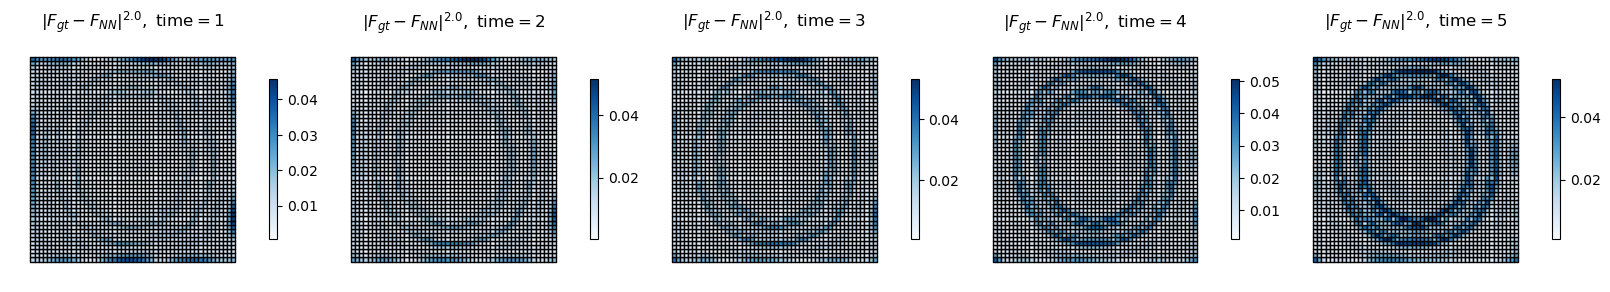

In [60]:
def lp_norm(array, p):
    return np.sum(np.abs(array) ** p, axis=(-2,-1)) ** (1 / p)
n_plots = len(u_hist_goh)  
n_cols = 5
n_rows = (n_plots + n_cols - 1) // n_cols 
fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
id_for_range=0
for idx, (t, F_gt, F) in enumerate(zip(t_hist, F_hist_goh_gt, F_hist_goh)):
    if id_for_range==n_cols:
        id_for_range=0
    ax_x = axes_x[idx]
    #F_error = np.linalg.norm(F_gt-F, axis=(1, 2), ord=1)
    ord=2
    F_error = lp_norm(F_gt-F,ord)
    label = fr'$|F_{{gt}}-F_{{NN}}|^{{{ord:.1f}}},\ \text{{time}}={t+1}$'
    plotmesh(mesh.cells, mesh.points, F_error,title=label, ax=ax_x)
    #F_noisy=F+noise
    #strains.append(np.array([t*np.ones(len(F)), F[:,0,0], F[:,0,1], F[:,1,0], F[:,1,1]]))
    id_for_range+=1

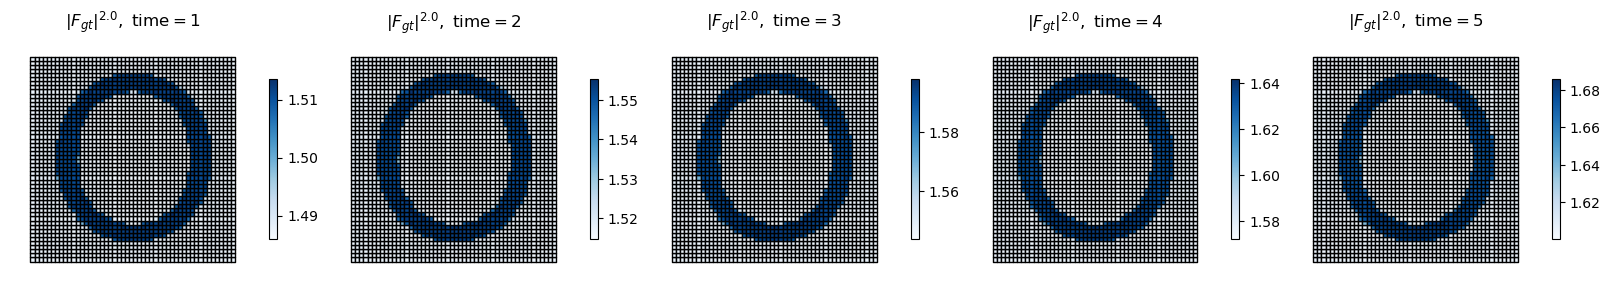

In [59]:
def lp_norm(array, p):
    return np.sum(np.abs(array) ** p, axis=(-2,-1)) ** (1 / p)
n_plots = len(u_hist_goh)  
n_cols = 5
n_rows = (n_plots + n_cols - 1) // n_cols 
fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
id_for_range=0
for idx, (t, F_gt, F) in enumerate(zip(t_hist, F_hist_goh_gt, F_hist_goh)):
    if id_for_range==n_cols:
        id_for_range=0
    ax_x = axes_x[idx]
    #F_error = np.linalg.norm(F_gt-F, axis=(1, 2), ord=1)
    ord=2
    F_error = lp_norm(F_gt,ord)
    label = fr'$|F_{{gt}}|^{{{ord:.1f}}},\ \text{{time}}={t+1}$'
    plotmesh(mesh.cells, mesh.points, F_error,title=label, ax=ax_x)
    #F_noisy=F+noise
    #strains.append(np.array([t*np.ones(len(F)), F[:,0,0], F[:,0,1], F[:,1,0], F[:,1,1]]))
    id_for_range+=1

ValueError: Invalid norm order for matrices.

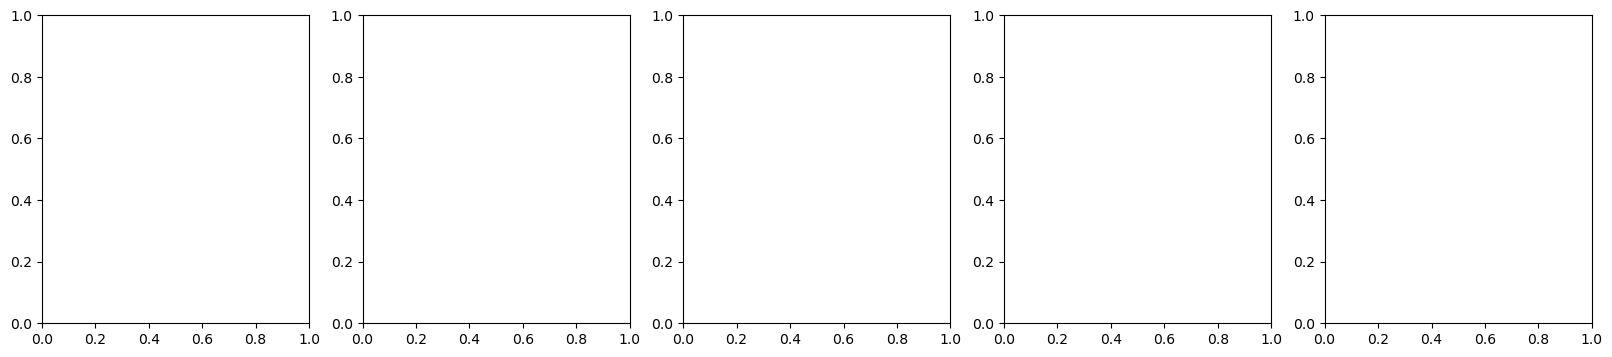

In [38]:
n_plots = len(u_hist_goh)  
n_cols = 5
n_rows = (n_plots + n_cols - 1) // n_cols 
fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
id_for_range=0
for idx, (t, F_gt, F) in enumerate(zip(t_hist, F_hist_goh_gt, F_hist_goh)):
    if id_for_range==n_cols:
        id_for_range=0
    ax_x = axes_x[idx]
    F_error = np.linalg.norm(F_gt-F, axis=(1, 2), ord=1.2)
    label = fr'$|F_{{gt}}-F_{{NN}}|^1,\ \text{{time}}={t+1}$'
    plotmesh(mesh.cells, mesh.points, F_error,title=label, ax=ax_x)
    #F_noisy=F+noise
    #strains.append(np.array([t*np.ones(len(F)), F[:,0,0], F[:,0,1], F[:,1,0], F[:,1,1]]))
    id_for_range+=1

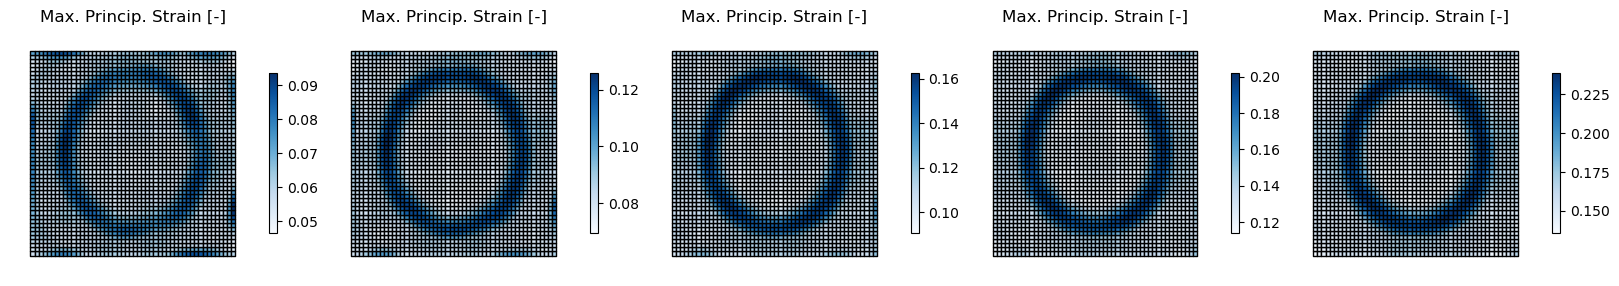

In [27]:
strains = []
t_hist = np.arange(len(u_hist_goh))
lmb_hist_plot = [1.05544, 1.07795, 1.10065, 1.12326, 1.14587]
n_plots = len(u_hist_goh)  
n_cols = 5
n_rows = (n_plots + n_cols - 1) // n_cols 
c_range=np.ones((n_cols,2))
c_range[:,[0]]=100000*c_range[:,[0]]
c_range[:,[1]]=-100000*c_range[:,[1]]
id_for_range=0
for i in range(n_rows):
    for j in range(n_cols):
        F=F_hist_goh[id_for_range,:,:,:]
        E = E_fun(F)
        evals, efuns = jnp.linalg.eigh(E)
        E_11, E_22 = evals.T
        ax_x = axes_x[idx]
        mps = np.maximum(E_11, E_22)
        c_range[j,0]=min(c_range[j,0],np.min(mps))
        c_range[j,1]=max(c_range[j,1],np.max(mps))
        id_for_range+=1
id_for_range=0
fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_x = axes_x.flatten()
for idx, (t, F, P) in enumerate(zip(t_hist, F_hist_goh, P_hist_goh)):
    if id_for_range==n_cols:
        id_for_range=0
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    ax_x = axes_x[idx]
    mps = np.maximum(E_11, E_22)
    plotmesh_updated(mesh.cells, mesh.points, mps, c_range[id_for_range,0], c_range[id_for_range,1],title='Max. Princip. Strain [-]', ax=ax_x)
    #F_noisy=F+noise
    strains.append(np.array([t*np.ones(len(F)), F[:,0,0], F[:,0,1], F[:,1,0], F[:,1,1]]))
    id_for_range+=1
strains_gt = np.hstack(strains)
#print(c_range)